# OWT Eval Sweep Plots

Compares finished W&B eval runs with prefix `owt_packed_loopholing_bptt_puma_eval_owt_`
across four model variants, three `top_p` values, and five threshold values.

**Variables**:
- `model`: last_layer_untied (100k & 400k), middle_layer_untied (100k), last_layer_tied (100k)
- `top_p`: 1.0, 0.9, 0.8
- `threshold`: 0.001, 0.01, 0.1, 0.15, 0.20

**Metrics**: `val/perplexity_gpt2` (conditional on generated tokens only), `val/total_perplexity_gpt2` (over full sequence including copied tokens), and `val/entropy_gpt2` (model entropy in nats at generation time — lower = more "peaked"/certain generation).

In [1]:
import sys, os
# Ensure repo root is on sys.path
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

In [2]:
import re
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

matplotlib.rcParams['figure.dpi'] = 130
matplotlib.rcParams['font.size'] = 11

## 1. Load data

Data fetched from W&B (`ilm-extensions/BPTT`) via MCP and embedded here for reproducibility.
Re-run the fetch cell below to refresh from live W&B.

In [3]:
# ── Embedded data (fetched 2026-04-20 via W&B GraphQL) ───────────────────────
# Columns: model_tag, step, threshold, top_p,
#          perplexity_gpt2, total_perplexity_gpt2, entropy_gpt2 (nats)
_RAW = [
    # last_layer_tied  100k
    ('last_layer_tied',   '100k', 0.001, 0.8, 92.074,  80.278,  4.8935),
    ('last_layer_tied',   '100k', 0.001, 0.9, 194.048, 165.619, 5.1963),
    ('last_layer_tied',   '100k', 0.001, 1.0, 530.218, 459.964, 5.5326),
    ('last_layer_tied',   '100k', 0.01,  0.8, 93.020,  82.532,  4.9230),
    ('last_layer_tied',   '100k', 0.01,  0.9, 190.734, 164.116, 5.1745),
    ('last_layer_tied',   '100k', 0.01,  1.0, 549.400, 482.646, 5.5653),
    ('last_layer_tied',   '100k', 0.1,   0.8, 92.205,  80.113,  4.8999),
    ('last_layer_tied',   '100k', 0.1,   0.9, 199.321, 173.294, 5.2185),
    ('last_layer_tied',   '100k', 0.1,   1.0, 562.420, 483.973, 5.5621),
    ('last_layer_tied',   '100k', 0.15,  0.8, 91.723,  78.005,  4.8681),
    ('last_layer_tied',   '100k', 0.15,  0.9, 206.194, 179.529, 5.2327),
    ('last_layer_tied',   '100k', 0.15,  1.0, 534.757, 468.565, 5.5515),
    ('last_layer_tied',   '100k', 0.20,  0.8, 89.415,  76.963,  4.8529),
    ('last_layer_tied',   '100k', 0.20,  0.9, 192.984, 167.076, 5.1995),
    ('last_layer_tied',   '100k', 0.20,  1.0, 576.009, 519.569, 5.6018),
    # last_layer_untied  100k
    ('last_layer_untied', '100k', 0.001, 0.8, 50.568,  43.662,  4.6878),
    ('last_layer_untied', '100k', 0.001, 0.9, 106.894, 96.361,  5.0944),
    ('last_layer_untied', '100k', 0.001, 1.0, 278.670, 255.107, 5.4517),
    ('last_layer_untied', '100k', 0.01,  0.8, 51.340,  43.540,  4.6557),
    ('last_layer_untied', '100k', 0.01,  0.9, 104.509, 92.285,  5.0479),
    ('last_layer_untied', '100k', 0.01,  1.0, 282.307, 264.423, 5.4655),
    ('last_layer_untied', '100k', 0.1,   0.8, 51.226,  44.466,  4.6945),
    ('last_layer_untied', '100k', 0.1,   0.9, 104.728, 94.115,  5.0757),
    ('last_layer_untied', '100k', 0.1,   1.0, 279.023, 259.986, 5.4563),
    ('last_layer_untied', '100k', 0.15,  0.8, 50.737,  43.838,  4.6651),
    ('last_layer_untied', '100k', 0.15,  0.9, 101.865, 90.110,  5.0372),
    ('last_layer_untied', '100k', 0.15,  1.0, 272.457, 248.106, 5.4207),
    ('last_layer_untied', '100k', 0.20,  0.8, 51.657,  44.088,  4.6585),
    ('last_layer_untied', '100k', 0.20,  0.9, 106.528, 96.937,  5.1103),
    ('last_layer_untied', '100k', 0.20,  1.0, 276.162, 255.139, 5.4377),
    # last_layer_untied  400k
    ('last_layer_untied', '400k', 0.001, 0.8, 31.628,  22.844,  4.3054),
    ('last_layer_untied', '400k', 0.001, 0.9, 91.412,  65.259,  4.8691),
    ('last_layer_untied', '400k', 0.001, 1.0, 379.965, 307.755, 5.4951),
    ('last_layer_untied', '400k', 0.01,  0.8, 31.670,  22.751,  4.3046),
    ('last_layer_untied', '400k', 0.01,  0.9, 87.136,  64.670,  4.8849),
    ('last_layer_untied', '400k', 0.01,  1.0, 384.038, 321.945, 5.5298),
    ('last_layer_untied', '400k', 0.1,   0.8, 30.546,  22.121,  4.2378),
    ('last_layer_untied', '400k', 0.1,   0.9, 92.718,  69.893,  4.9450),
    ('last_layer_untied', '400k', 0.1,   1.0, 381.835, 322.777, 5.5313),
    ('last_layer_untied', '400k', 0.15,  0.8, 30.183,  21.841,  4.2390),
    ('last_layer_untied', '400k', 0.15,  0.9, 88.510,  66.595,  4.9092),
    ('last_layer_untied', '400k', 0.15,  1.0, 389.088, 325.585, 5.5348),
    ('last_layer_untied', '400k', 0.20,  0.8, 31.335,  22.674,  4.2635),
    ('last_layer_untied', '400k', 0.20,  0.9, 90.535,  69.311,  4.9233),
    ('last_layer_untied', '400k', 0.20,  1.0, 381.178, 326.839, 5.5432),
    # middle_layer_untied  100k
    ('middle_layer_untied', '100k', 0.001, 0.8, 57.209,  30.971,  3.0481),
    ('middle_layer_untied', '100k', 0.001, 0.9, 106.135, 58.962,  3.4496),
    ('middle_layer_untied', '100k', 0.001, 1.0, 236.110, 143.628, 3.9450),
    ('middle_layer_untied', '100k', 0.01,  0.8, 56.135,  31.546,  3.0627),
    ('middle_layer_untied', '100k', 0.01,  0.9, 104.098, 58.111,  3.4542),
    ('middle_layer_untied', '100k', 0.01,  1.0, 231.426, 144.868, 3.9524),
    ('middle_layer_untied', '100k', 0.1,   0.8, 54.863,  29.665,  2.9894),
    ('middle_layer_untied', '100k', 0.1,   0.9, 102.109, 56.539,  3.4135),
    ('middle_layer_untied', '100k', 0.1,   1.0, 222.938, 130.964, 3.8695),
    ('middle_layer_untied', '100k', 0.15,  0.8, 52.730,  28.030,  2.9572),
    ('middle_layer_untied', '100k', 0.15,  0.9, 90.749,  50.257,  3.3294),
    ('middle_layer_untied', '100k', 0.15,  1.0, 219.312, 133.675, 3.8753),
    ('middle_layer_untied', '100k', 0.20,  0.8, 53.111,  29.441,  2.9979),
    ('middle_layer_untied', '100k', 0.20,  0.9, 95.227,  50.963,  3.3522),
    ('middle_layer_untied', '100k', 0.20,  1.0, 221.860, 132.324, 3.8819),
]

df = pd.DataFrame(_RAW, columns=['model', 'step', 'threshold', 'top_p',
                                   'perplexity_gpt2', 'total_perplexity_gpt2',
                                   'entropy_gpt2'])
df['model_label'] = df['model'] + ' (' + df['step'] + ')'


def _mlm_uniform_100k_row():
    """Scalars for MLM-uniform @ 100k checkpoint eval (W&B run un359qeh).

    Preferred: read val/*_gpt2 from the eval run summary when present.
    Fallback: last validation scalars from training run owt_packed_mlm_v2 (ilm/mlm),
    because eval run un359qeh currently logs only a prediction table, not these scalars.
    """
    eval_run = 'ilm-extensions/mlm/un359qeh'
    fallback_run = 'ilm-extensions/mlm/owt_packed_mlm_v2'
    keys = ('val/perplexity_gpt2', 'val/total_perplexity_gpt2', 'val/entropy_gpt2')
    try:
        import wandb
        api = wandb.Api()
        r = api.run(eval_run)
        if all(k in r.summary for k in keys):
            return {
                'perplexity_gpt2': float(r.summary['val/perplexity_gpt2']),
                'total_perplexity_gpt2': float(r.summary['val/total_perplexity_gpt2']),
                'entropy_gpt2': float(r.summary['val/entropy_gpt2']),
                'source': eval_run + ' (summary)',
            }
        r2 = api.run(fallback_run)
        if all(k in r2.summary for k in keys):
            print(
                'Note: MLM-uniform (100k): eval run un359qeh has no scalar val/*_gpt2 in '
                'summary; using GPT-2 metrics from training run owt_packed_mlm_v2 summary.'
            )
            return {
                'perplexity_gpt2': float(r2.summary['val/perplexity_gpt2']),
                'total_perplexity_gpt2': float(r2.summary['val/total_perplexity_gpt2']),
                'entropy_gpt2': float(r2.summary['val/entropy_gpt2']),
                'source': fallback_run + ' (summary fallback)',
            }
    except Exception as e:
        print('MLM-uniform fetch skipped:', e)
    # Embedded fallback (matches owt_packed_mlm_v2 summary at last val; refresh via wandb when eval logs scalars)
    return {
        'perplexity_gpt2': 9.79441661387682,
        'total_perplexity_gpt2': 8.223577499389648,
        'entropy_gpt2': 3.9672594144940376,
        'source': 'embedded (owt_packed_mlm_v2 last val)',
    }


_mlm = _mlm_uniform_100k_row()
df = pd.concat(
    [
        df,
        pd.DataFrame(
            [
                {
                    'model': 'mlm_uniform',
                    'step': '100k',
                    'threshold': 0.15,
                    'top_p': 1.0,
                    'perplexity_gpt2': _mlm['perplexity_gpt2'],
                    'total_perplexity_gpt2': _mlm['total_perplexity_gpt2'],
                    'entropy_gpt2': _mlm['entropy_gpt2'],
                    'model_label': 'MLM-uniform (100k)',
                }
            ]
        ),
    ],
    ignore_index=True,
)
print(df.shape, 'rows')
df.head()


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/brozonoyer_umass_edu/.netrc.


Note: MLM-uniform (100k): eval run un359qeh has no scalar val/*_gpt2 in summary; using GPT-2 metrics from training run owt_packed_mlm_v2 summary.
(61, 8) rows


,model,step,threshold,top_p,perplexity_gpt2,total_perplexity_gpt2,entropy_gpt2,model_label
0,last_layer_tied,100k,0.001,0.8,92.074,80.278,4.8935,last_layer_tied (100k)
1,last_layer_tied,100k,0.001,0.9,194.048,165.619,5.1963,last_layer_tied (100k)
2,last_layer_tied,100k,0.001,1.0,530.218,459.964,5.5326,last_layer_tied (100k)
3,last_layer_tied,100k,0.010,0.8,93.020,82.532,4.9230,last_layer_tied (100k)
4,last_layer_tied,100k,0.010,0.9,190.734,164.116,5.1745,last_layer_tied (100k)


In [4]:
# ── Optional: re-fetch live from W&B ─────────────────────────────────────────
# Uncomment and run this cell to pull fresh data instead of using the embedded dict above.

# import wandb
# api = wandb.Api()
# runs = api.runs(
#     'ilm-extensions/BPTT',
#     filters={
#         'displayName': {'$regex': r'^owt_packed_loopholing_bptt_puma_eval_owt_'},
#         'state': 'finished',
#     }
# )
# _PATTERN = re.compile(
#     r'owt_packed_loopholing_bptt_puma_eval_owt_'
#     r'(?P<model>(?:last|middle)_layer_(?:un)?tied)'
#     r'_(?P<step>\d+-\d+)_top_prob'
#     r'_(?P<threshold>[\d.]+)_(?P<top_p>[\d.]+)_\d+'
# )
# rows = []
# for run in runs:
#     m = _PATTERN.match(run.name)
#     if not m:
#         continue
#     step_label = '100k' if m['step'].endswith('100000') else '400k'
#     rows.append({
#         'model': m['model'],
#         'step': step_label,
#         'threshold': float(m['threshold']),
#         'top_p': float(m['top_p']),
#         'perplexity_gpt2': run.summary.get('val/perplexity_gpt2'),
#         'total_perplexity_gpt2': run.summary.get('val/total_perplexity_gpt2'),
#         'entropy_gpt2': run.summary.get('val/entropy_gpt2'),
#     })
# df = pd.DataFrame(rows)
# df['model_label'] = df['model'] + ' (' + df['step'] + ')'
# print(df.shape, 'rows')

## 2. Plotting helpers

In [5]:
MODEL_ORDER = [
    'last_layer_untied (400k)',
    'last_layer_untied (100k)',
    'middle_layer_untied (100k)',
    'last_layer_tied (100k)',
]
MODEL_COLORS = {
    'last_layer_untied (400k)':   '#1f77b4',   # blue
    'last_layer_untied (100k)':   '#ff7f0e',   # orange
    'middle_layer_untied (100k)': '#2ca02c',   # green
    'last_layer_tied (100k)':     '#d62728',   # red
}
MODEL_MARKERS = {
    'last_layer_untied (400k)':   'o',
    'last_layer_untied (100k)':   's',
    'middle_layer_untied (100k)': '^',
    'last_layer_tied (100k)':     'D',
}
THRESHOLDS = sorted(df['threshold'].unique())
TOP_PS = [0.8, 0.9, 1.0]

## 3. Plot A — `val/total_perplexity_gpt2` vs threshold, all models, by top_p

Each column is a `top_p` value; each line is a model.  
`total_perplexity_gpt2` measures GPT-2 perplexity on the **full** generated sequence (copied + generated tokens).

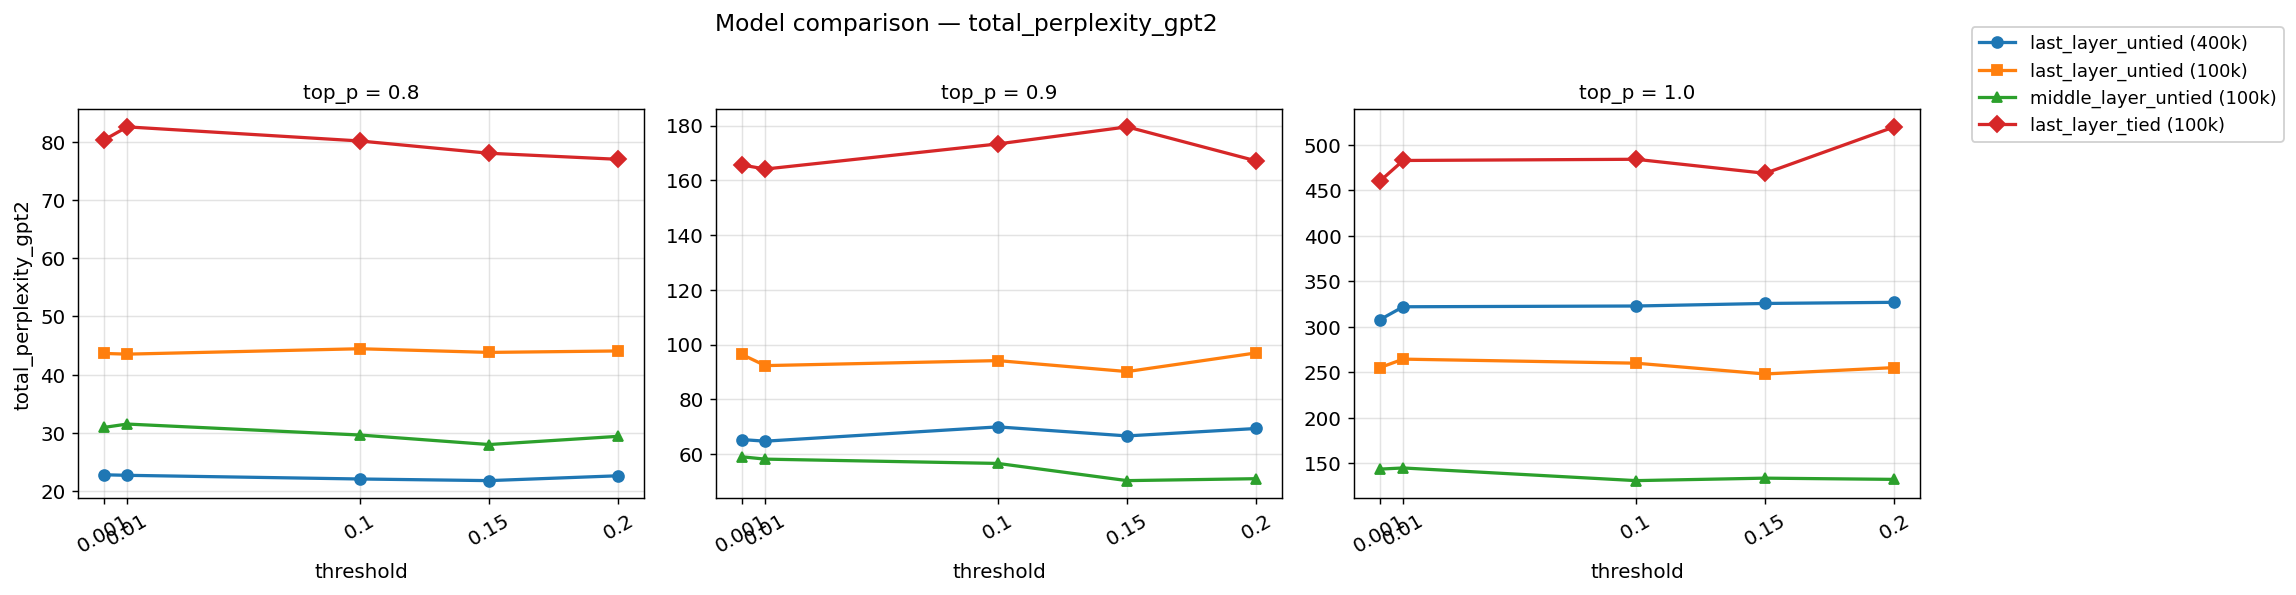

In [6]:
def plot_metric_vs_threshold_by_topp(metric, ylabel, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
    fig.suptitle(f'{title_prefix} — {metric}', fontsize=13, y=1.01)

    for ax, tp in zip(axes, TOP_PS):
        sub = df[df['top_p'] == tp]
        for model in MODEL_ORDER:
            row = sub[sub['model_label'] == model].sort_values('threshold')
            if row.empty:
                continue
            ax.plot(
                row['threshold'], row[metric],
                marker=MODEL_MARKERS[model],
                color=MODEL_COLORS[model],
                label=model,
                linewidth=1.8,
                markersize=6,
            )
        ax.set_title(f'top_p = {tp}', fontsize=11)
        ax.set_xlabel('threshold')
        ax.set_ylabel(ylabel if ax is axes[0] else '')
        ax.set_xticks(THRESHOLDS)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3g'))
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, alpha=0.35)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.18, 1.0),
               framealpha=0.9, fontsize=10)
    fig.tight_layout()
    plt.show()


plot_metric_vs_threshold_by_topp(
    'total_perplexity_gpt2',
    'total_perplexity_gpt2',
    'Model comparison'
)

## 4. Plot B — `val/perplexity_gpt2` vs threshold, all models, by top_p

`perplexity_gpt2` is measured **only over the tokens the model generated** (not the copied prefix).  
Higher threshold → more aggressive generation → harder for GPT-2 to predict.

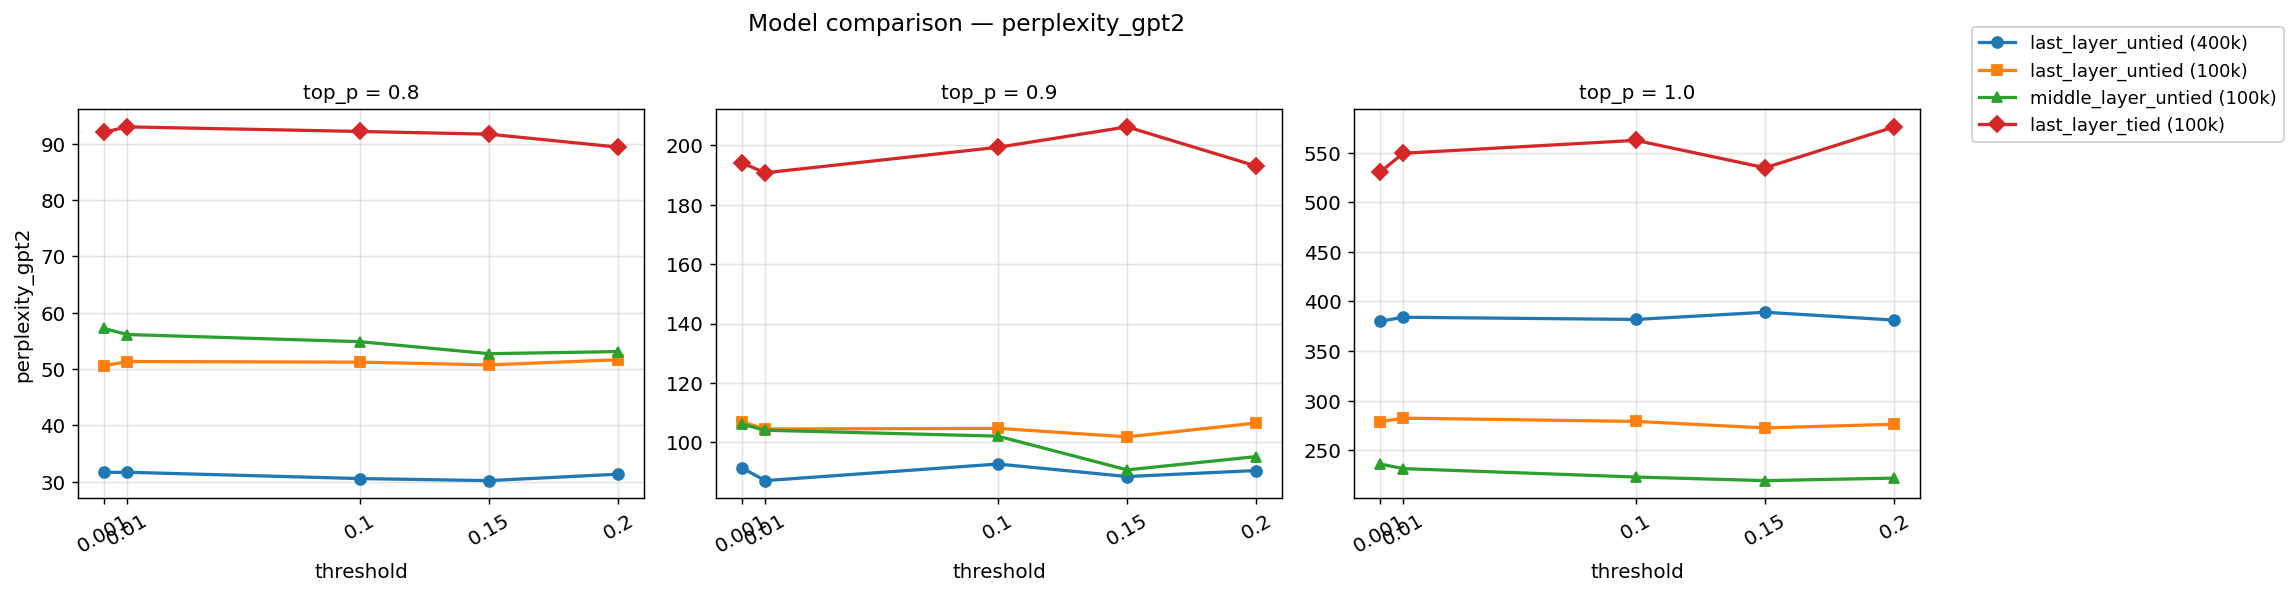

In [7]:
plot_metric_vs_threshold_by_topp(
    'perplexity_gpt2',
    'perplexity_gpt2',
    'Model comparison'
)

## 5. Plot C — Both metrics side-by-side per model, across all top_p

Each row is a model; left column = `total_perplexity_gpt2`, right = `perplexity_gpt2`.  
Lines are coloured by `top_p`.  Useful for seeing the ppl gap (copied vs generated only).

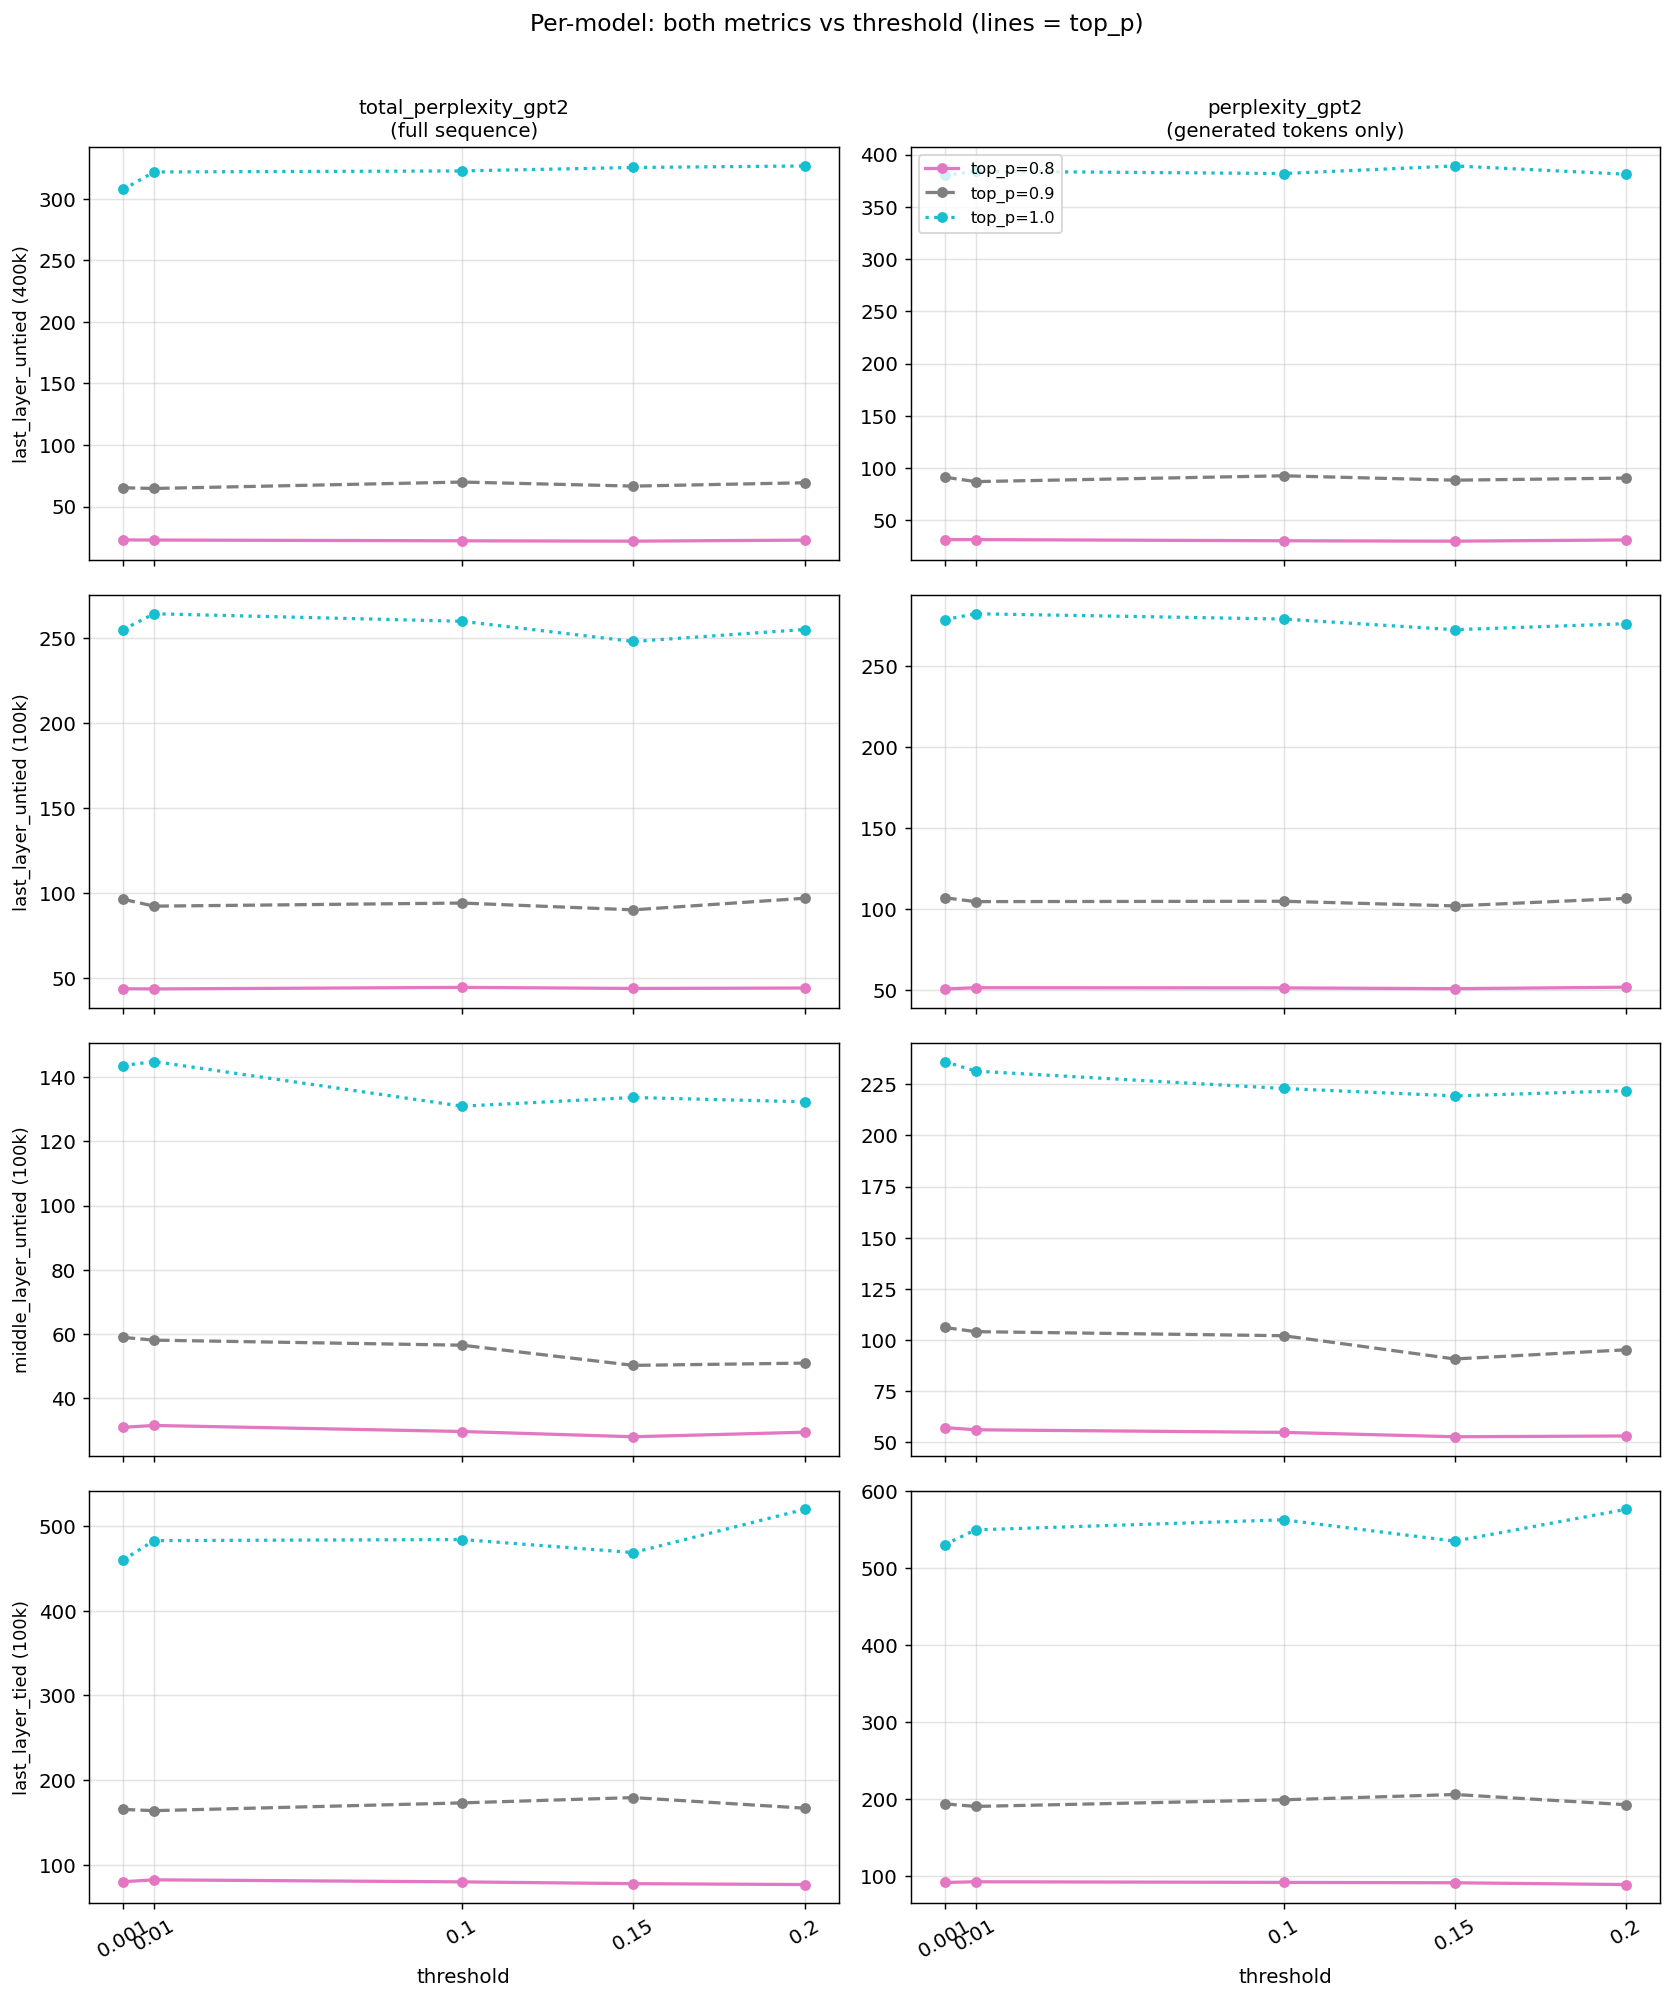

In [8]:
TOPP_COLORS = {0.8: '#e377c2', 0.9: '#7f7f7f', 1.0: '#17becf'}
TOPP_STYLES = {0.8: '-', 0.9: '--', 1.0: ':'}

fig, axes = plt.subplots(len(MODEL_ORDER), 2, figsize=(13, 3.8 * len(MODEL_ORDER)),
                          sharex=True)
fig.suptitle('Per-model: both metrics vs threshold (lines = top_p)', fontsize=13, y=1.01)

metrics = ['total_perplexity_gpt2', 'perplexity_gpt2']
metric_labels = ['total_perplexity_gpt2\n(full sequence)', 'perplexity_gpt2\n(generated tokens only)']

for row_i, model in enumerate(MODEL_ORDER):
    sub = df[df['model_label'] == model]
    for col_i, (metric, mlabel) in enumerate(zip(metrics, metric_labels)):
        ax = axes[row_i][col_i]
        for tp in TOP_PS:
            d = sub[sub['top_p'] == tp].sort_values('threshold')
            ax.plot(
                d['threshold'], d[metric],
                marker='o', markersize=5,
                color=TOPP_COLORS[tp],
                linestyle=TOPP_STYLES[tp],
                label=f'top_p={tp}',
                linewidth=1.8,
            )
        ax.set_xticks(THRESHOLDS)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3g'))
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, alpha=0.35)
        if col_i == 0:
            ax.set_ylabel(model, fontsize=10)
        if row_i == 0:
            ax.set_title(mlabel, fontsize=11)
        if row_i == len(MODEL_ORDER) - 1:
            ax.set_xlabel('threshold')
        if row_i == 0 and col_i == 1:
            ax.legend(fontsize=9, loc='upper left')

fig.tight_layout()
plt.show()

## 6. Plot D — Heatmaps: `total_perplexity_gpt2` and `perplexity_gpt2`

Rows = (model × top_p), columns = threshold.  
Quick overview of the full 4 × 3 × 5 grid at a glance.

/tmp/ipykernel_2162760/2782894488.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


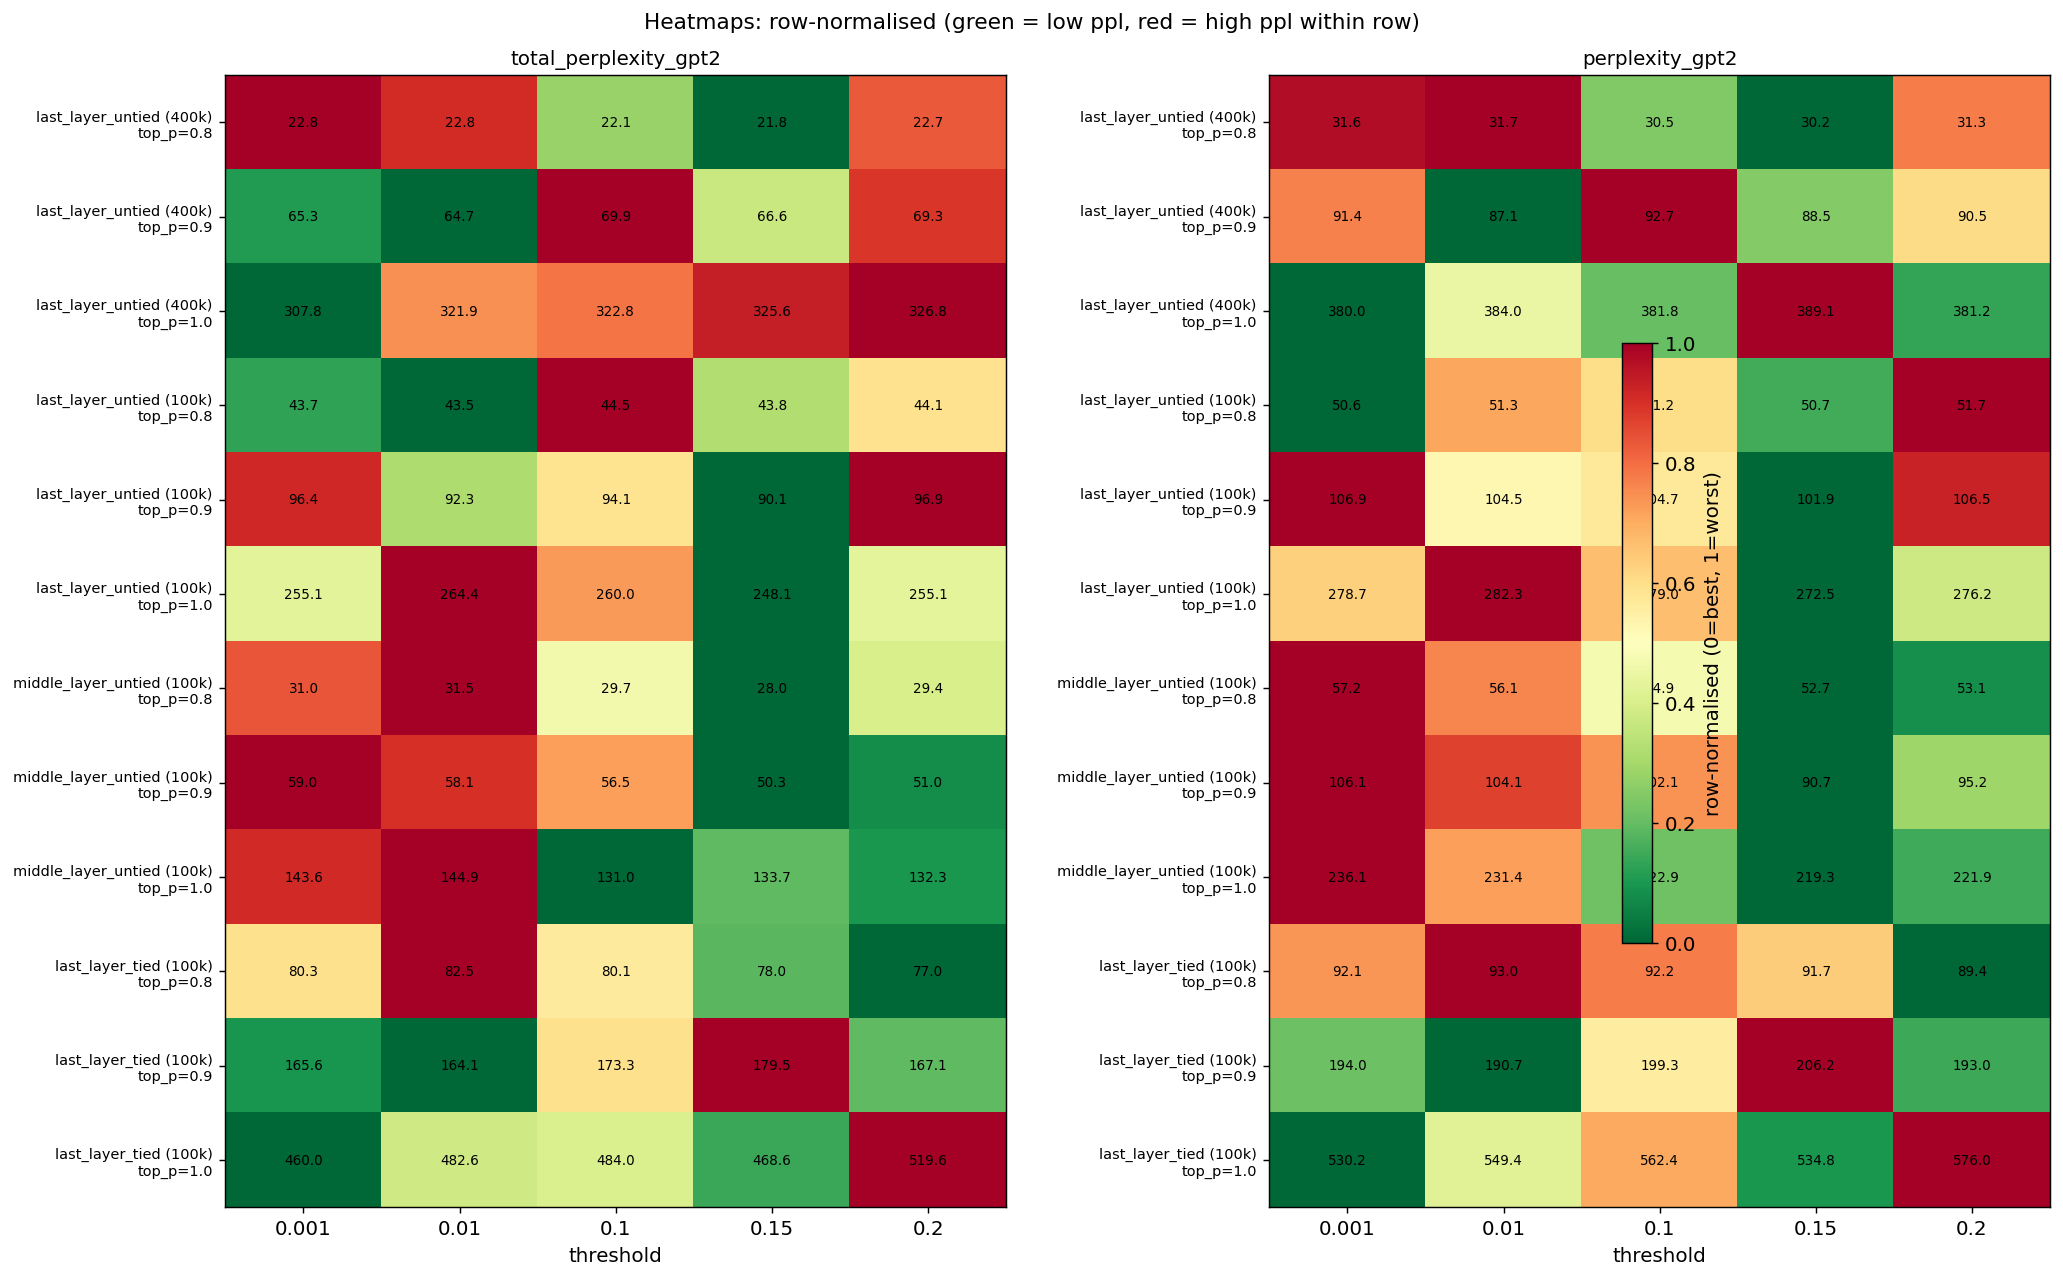

In [9]:
def make_heatmap(metric, ax, title):
    row_keys = [(m, tp) for m in MODEL_ORDER for tp in TOP_PS]
    row_labels = [f'{m}\ntop_p={tp}' for m, tp in row_keys]
    col_labels = [str(t) for t in THRESHOLDS]

    matrix = np.full((len(row_keys), len(THRESHOLDS)), np.nan)
    for ri, (model, tp) in enumerate(row_keys):
        sub = df[(df['model_label'] == model) & (df['top_p'] == tp)]
        for ci, thr in enumerate(THRESHOLDS):
            val = sub[sub['threshold'] == thr][metric]
            if not val.empty:
                matrix[ri, ci] = val.values[0]

    # Normalise per row to see relative threshold sensitivity
    row_min = np.nanmin(matrix, axis=1, keepdims=True)
    row_max = np.nanmax(matrix, axis=1, keepdims=True)
    normed = (matrix - row_min) / (row_max - row_min + 1e-9)

    im = ax.imshow(normed, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
    ax.set_xticks(range(len(THRESHOLDS)))
    ax.set_xticklabels(col_labels)
    ax.set_yticks(range(len(row_keys)))
    ax.set_yticklabels(row_labels, fontsize=8)
    ax.set_xlabel('threshold')
    ax.set_title(title, fontsize=11)

    for ri in range(len(row_keys)):
        for ci in range(len(THRESHOLDS)):
            val = matrix[ri, ci]
            if not np.isnan(val):
                ax.text(ci, ri, f'{val:.1f}', ha='center', va='center',
                        fontsize=7.5, color='black')
    return im


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
fig.suptitle('Heatmaps: row-normalised (green = low ppl, red = high ppl within row)', fontsize=12)

make_heatmap('total_perplexity_gpt2', ax1, 'total_perplexity_gpt2')
im = make_heatmap('perplexity_gpt2', ax2, 'perplexity_gpt2')

fig.colorbar(im, ax=[ax1, ax2], shrink=0.6, label='row-normalised (0=best, 1=worst)')
fig.tight_layout()
plt.show()

## 7. Plot E — Best-threshold comparison bar chart

For each (model, top_p) pair, show the **minimum** `total_perplexity_gpt2` across thresholds  
(i.e., best-case performance under optimal threshold tuning).

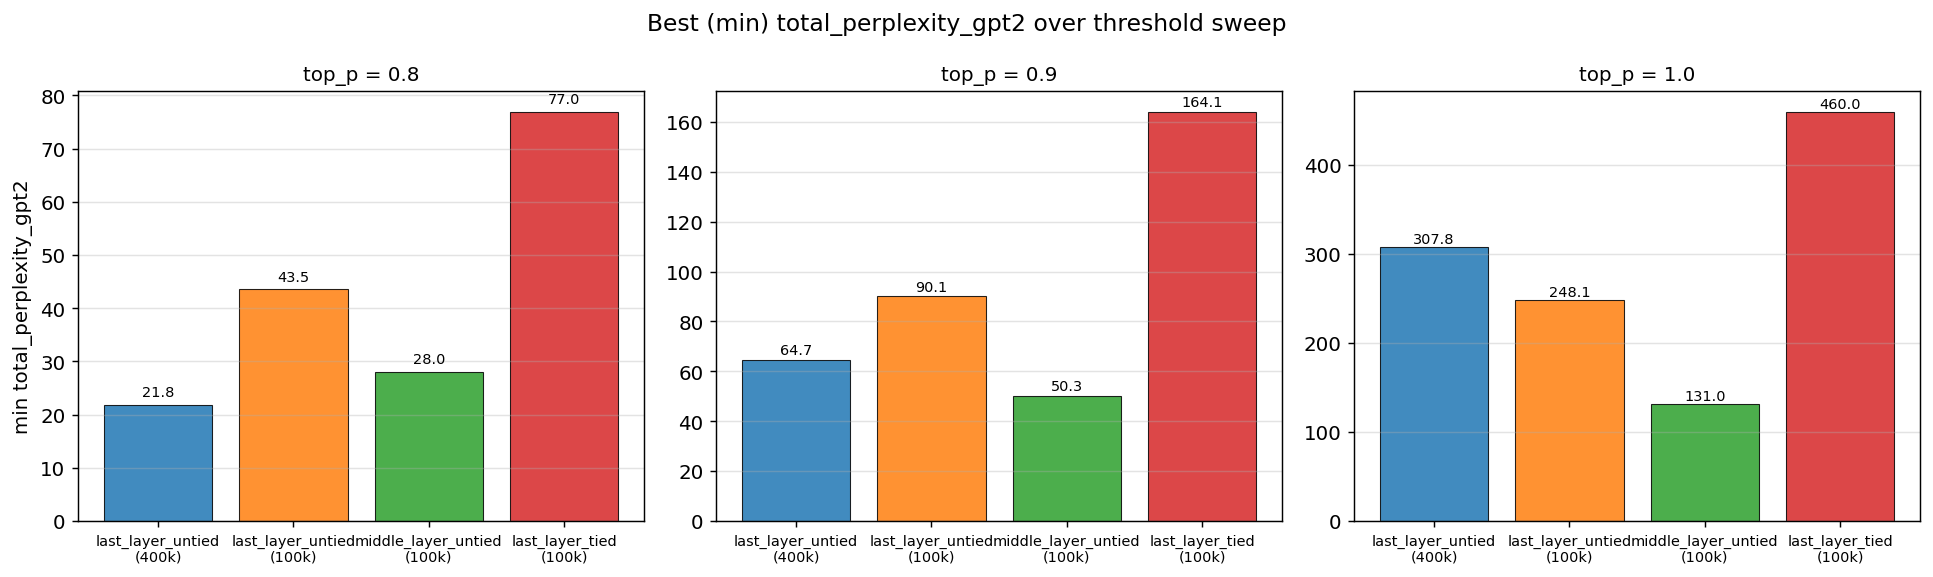

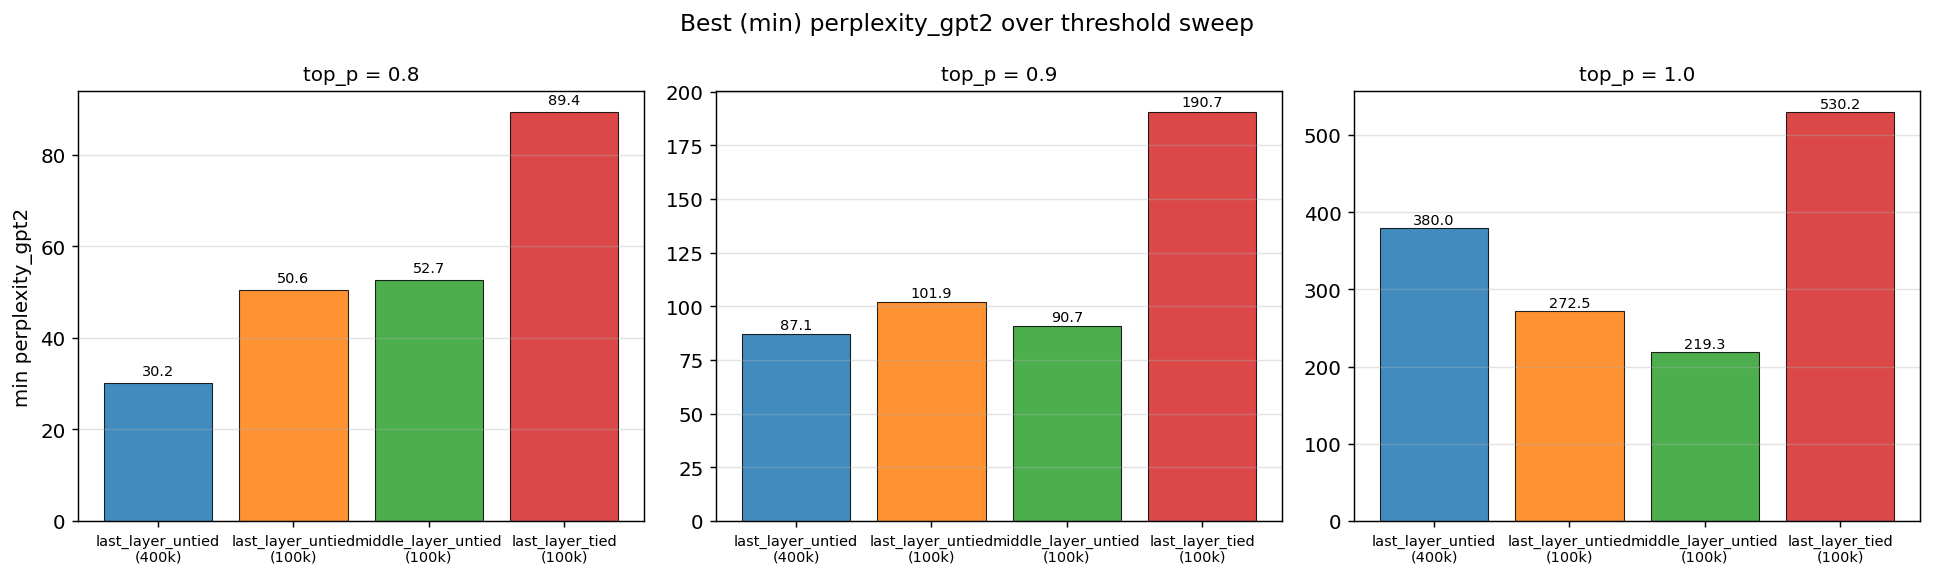

In [10]:
def best_threshold_bars(metric, ylabel):
    best = (
        df.groupby(['model_label', 'top_p'])[metric]
        .min()
        .reset_index()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
    fig.suptitle(f'Best (min) {metric} over threshold sweep', fontsize=13)

    for ax, tp in zip(axes, TOP_PS):
        sub = best[best['top_p'] == tp].set_index('model_label').reindex(MODEL_ORDER)
        colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
        bars = ax.bar(range(len(MODEL_ORDER)), sub[metric], color=colors, alpha=0.85,
                       edgecolor='black', linewidth=0.6)
        for bar, val in zip(bars, sub[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=8)
        ax.set_title(f'top_p = {tp}', fontsize=11)
        ax.set_xticks(range(len(MODEL_ORDER)))
        ax.set_xticklabels(
            [m.replace(' (', '\n(') for m in MODEL_ORDER],
            fontsize=8, rotation=0
        )
        ax.set_ylabel(ylabel if ax is axes[0] else '')
        ax.grid(True, axis='y', alpha=0.35)

    fig.tight_layout()
    plt.show()


best_threshold_bars('total_perplexity_gpt2', 'min total_perplexity_gpt2')
best_threshold_bars('perplexity_gpt2', 'min perplexity_gpt2')

## 8. Plot F — ppl gap: `perplexity_gpt2 − total_perplexity_gpt2`

The difference between the two metrics reflects the quality of the *copied* tokens relative to the *generated* ones.  
A large gap means the model copies easy (low-ppl) tokens and generates harder ones.  
The `middle_layer_untied` model has the largest gap, suggesting it copies especially fluent prefixes.

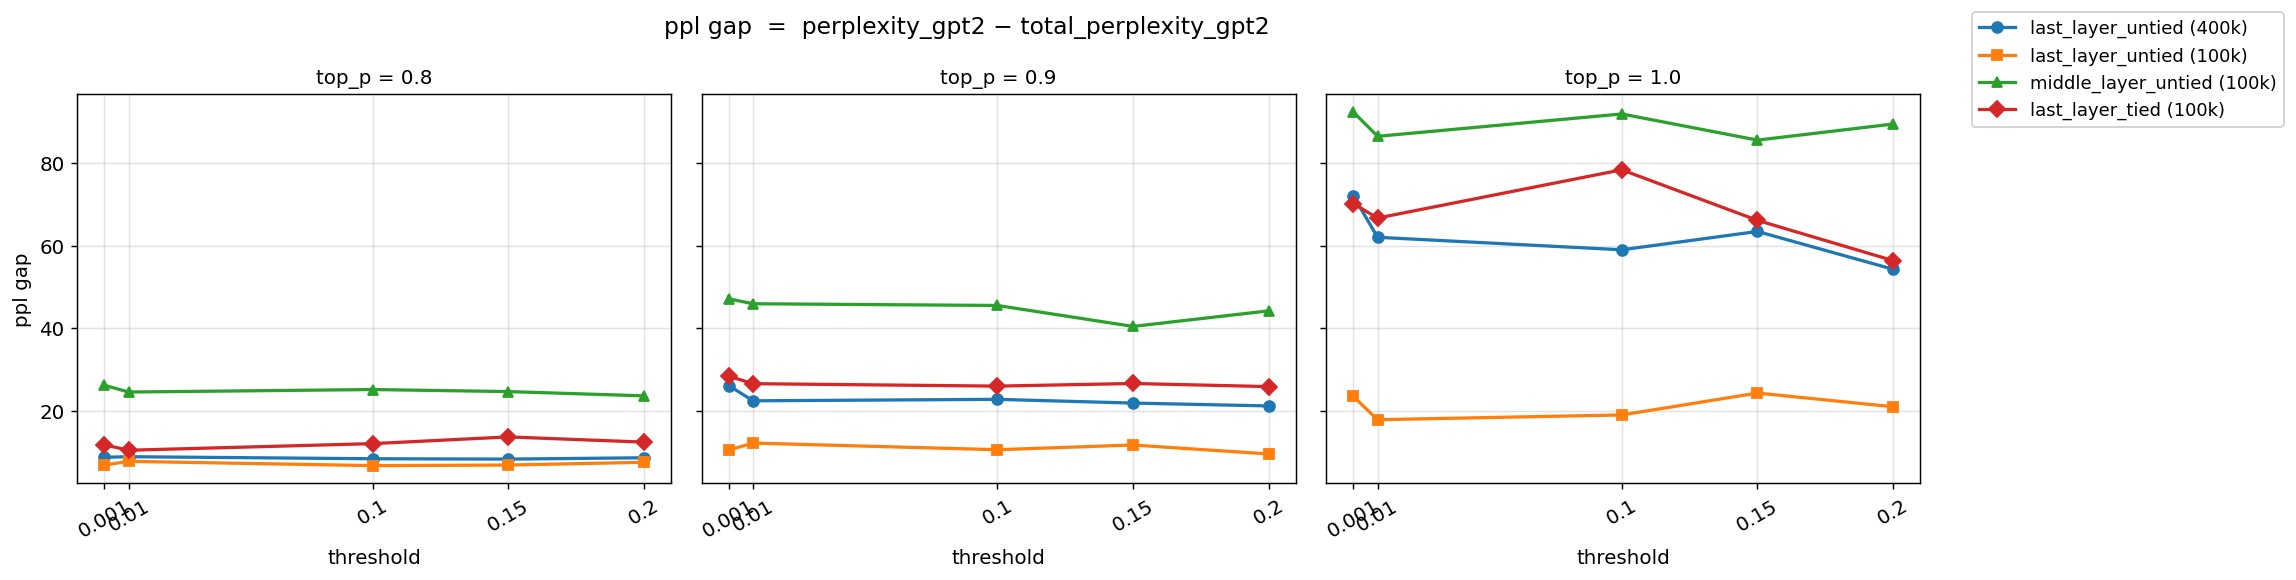

In [11]:
df['ppl_gap'] = df['perplexity_gpt2'] - df['total_perplexity_gpt2']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
fig.suptitle('ppl gap  =  perplexity_gpt2 − total_perplexity_gpt2', fontsize=13)

for ax, tp in zip(axes, TOP_PS):
    sub = df[df['top_p'] == tp]
    for model in MODEL_ORDER:
        row = sub[sub['model_label'] == model].sort_values('threshold')
        if row.empty:
            continue
        ax.plot(
            row['threshold'], row['ppl_gap'],
            marker=MODEL_MARKERS[model],
            color=MODEL_COLORS[model],
            label=model,
            linewidth=1.8,
            markersize=6,
        )
    ax.set_title(f'top_p = {tp}', fontsize=11)
    ax.set_xlabel('threshold')
    ax.set_ylabel('ppl gap' if ax is axes[0] else '')
    ax.set_xticks(THRESHOLDS)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3g'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.35)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.18, 1.0),
           framealpha=0.9, fontsize=10)
fig.tight_layout()
plt.show()

## 9. Plot G — `val/entropy_gpt2` vs threshold, all models, by top_p

`entropy_gpt2` is the model's generation-time entropy in nats (averaged over generated positions).  
Lower entropy = the model is more "peaked"/certain when generating.  
**`middle_layer_untied` stands out with ~1.5–2 nats lower entropy than all other models**, even though
its `perplexity_gpt2` is similar — meaning it generates more predictable (for itself) tokens while GPT-2
still assigns a moderately similar likelihood to them.

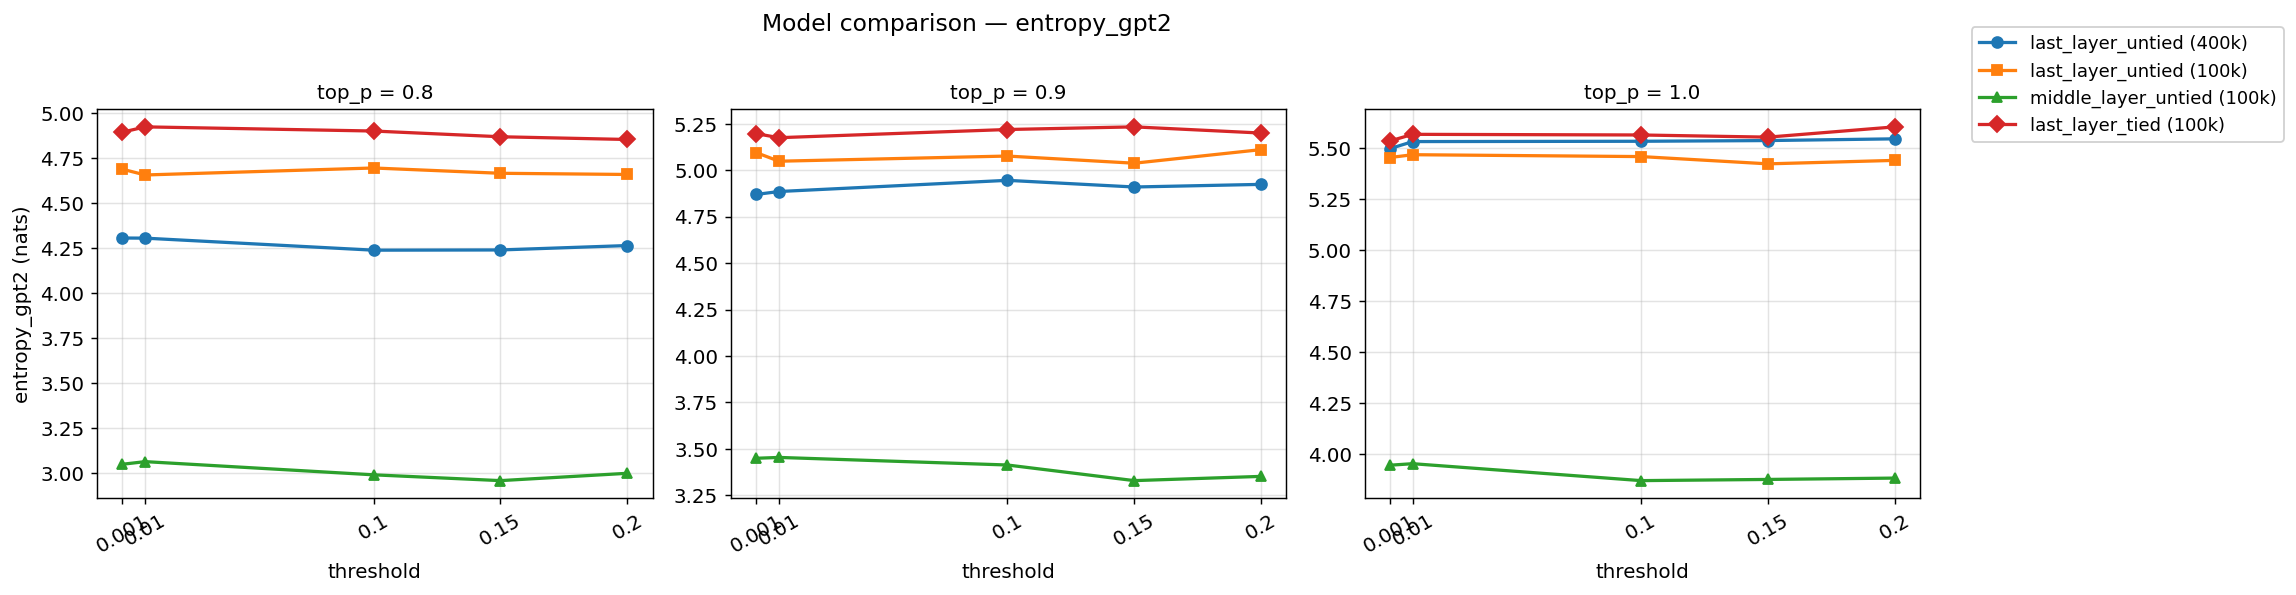

In [12]:
plot_metric_vs_threshold_by_topp(
    'entropy_gpt2',
    'entropy_gpt2 (nats)',
    'Model comparison'
)

## 10. Plot H — Three-metric per-model grid (total_ppl, perplexity_gpt2, entropy_gpt2)

Each row = one model; three columns show `total_perplexity_gpt2`, `perplexity_gpt2`, and `entropy_gpt2`
side-by-side vs threshold (lines = `top_p`).  
This is the clearest view of how the three metrics relate within each model.

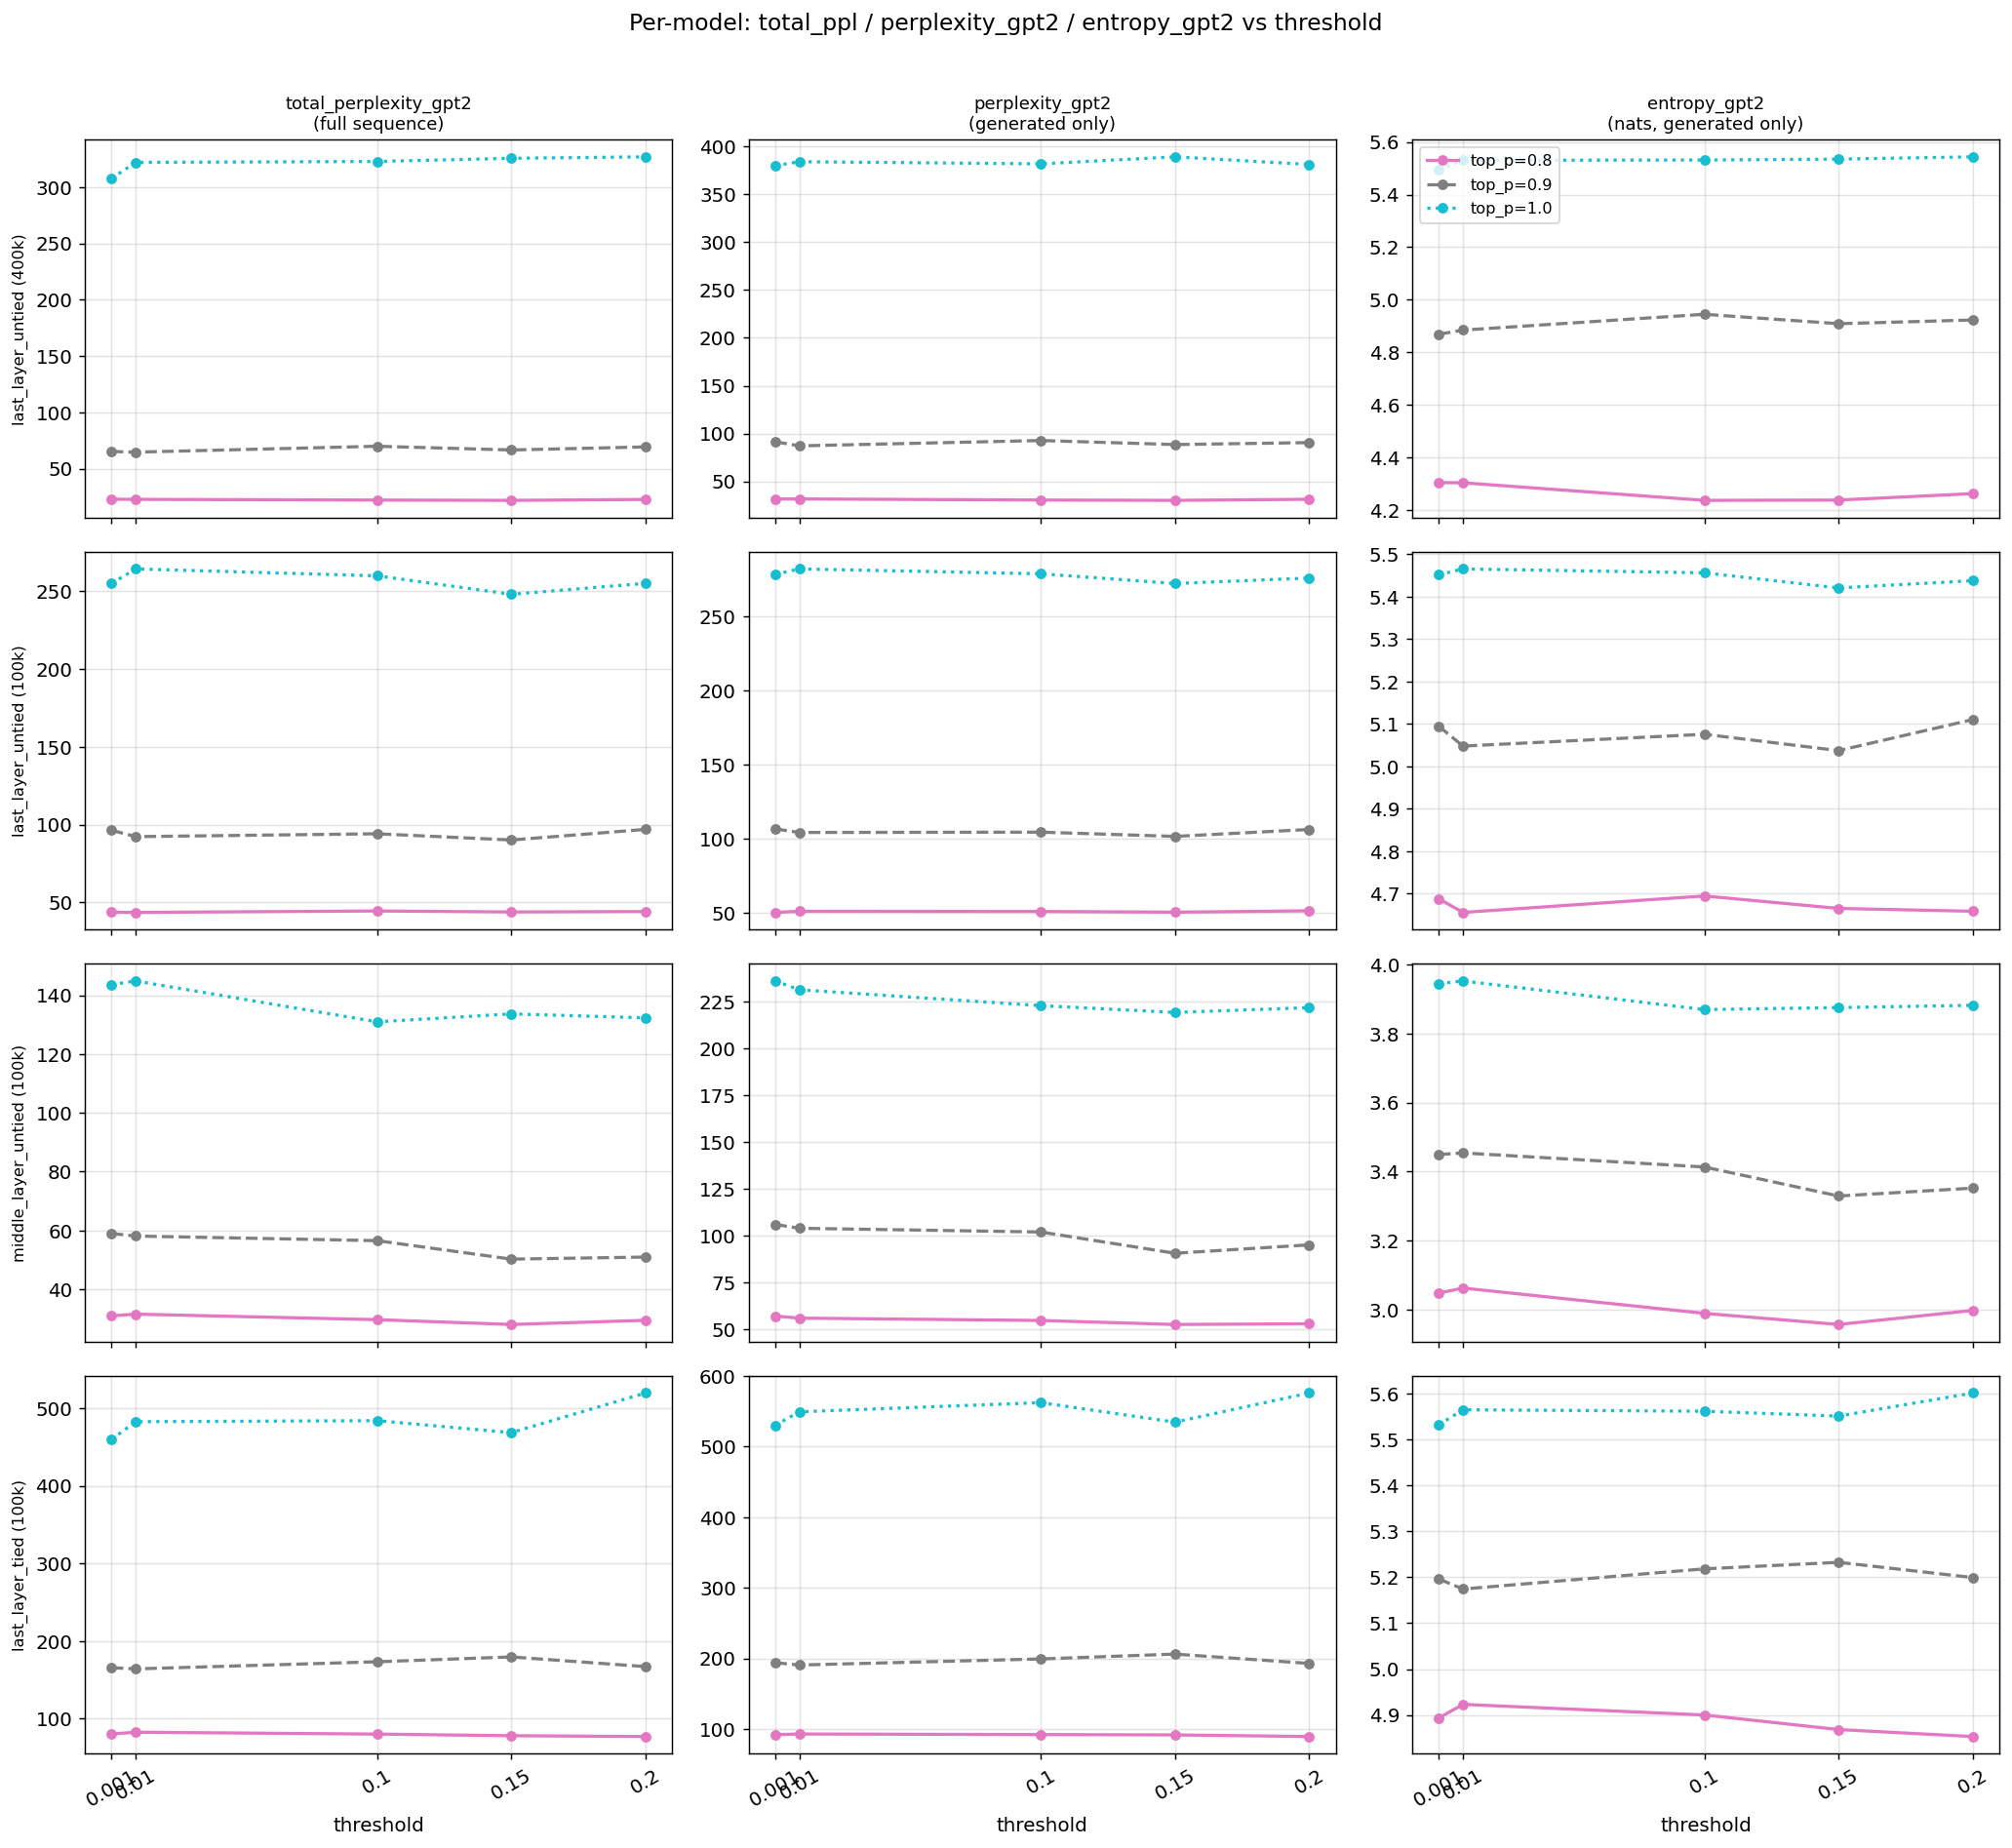

In [13]:
three_metrics = [
    ('total_perplexity_gpt2', 'total_perplexity_gpt2\n(full sequence)'),
    ('perplexity_gpt2',       'perplexity_gpt2\n(generated only)'),
    ('entropy_gpt2',          'entropy_gpt2\n(nats, generated only)'),
]

fig, axes = plt.subplots(len(MODEL_ORDER), 3,
                          figsize=(16, 3.6 * len(MODEL_ORDER)), sharex=True)
fig.suptitle('Per-model: total_ppl / perplexity_gpt2 / entropy_gpt2 vs threshold',
             fontsize=13, y=1.01)

for row_i, model in enumerate(MODEL_ORDER):
    sub = df[df['model_label'] == model]
    for col_i, (metric, mlabel) in enumerate(three_metrics):
        ax = axes[row_i][col_i]
        for tp in TOP_PS:
            d = sub[sub['top_p'] == tp].sort_values('threshold')
            ax.plot(
                d['threshold'], d[metric],
                marker='o', markersize=5,
                color=TOPP_COLORS[tp],
                linestyle=TOPP_STYLES[tp],
                label=f'top_p={tp}',
                linewidth=1.8,
            )
        ax.set_xticks(THRESHOLDS)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3g'))
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, alpha=0.35)
        if col_i == 0:
            ax.set_ylabel(model, fontsize=9)
        if row_i == 0:
            ax.set_title(mlabel, fontsize=10)
        if row_i == len(MODEL_ORDER) - 1:
            ax.set_xlabel('threshold')
        if row_i == 0 and col_i == 2:
            ax.legend(fontsize=9, loc='upper left')

fig.tight_layout()
plt.show()

## 11. Plot I — Scatter: `total_perplexity_gpt2` vs `entropy_gpt2`

Each point is one (model, threshold, top_p) eval run.  
**Shape** encodes `top_p`; **colour** encodes model; **size** encodes threshold (larger = higher threshold).  
This plot answers: *does lower generation entropy correlate with lower GPT-2 perplexity?*  
`middle_layer_untied` occupies a unique low-entropy / low-total-ppl regime that no other 100k model reaches.

**MLM-uniform (100k)** is the checkpoint eval [un359qeh](https://wandb.ai/ilm-extensions/mlm/runs/un359qeh) (`top_p=1.0`, `threshold=0.15`). The data cell loads `val/perplexity_gpt2`, `val/total_perplexity_gpt2`, and `val/entropy_gpt2` from that run’s W&B summary when present; if the eval run only logged the prediction table, it falls back to the last scalar validation on training run `owt_packed_mlm_v2` in the same project (see printed note).


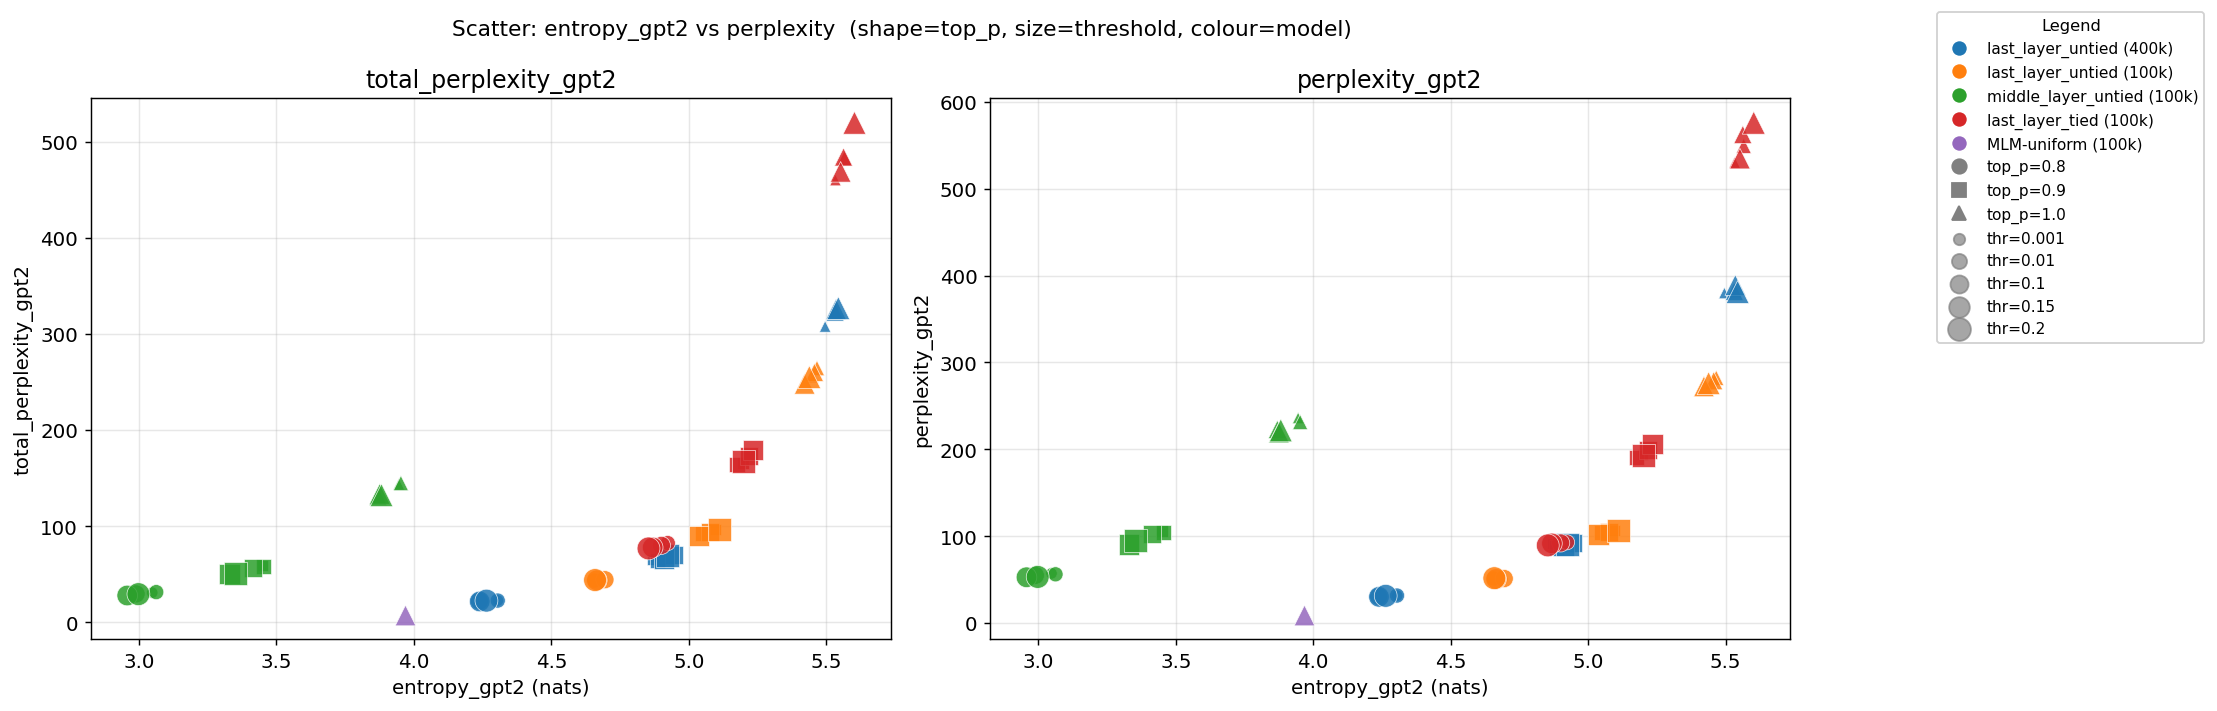

In [14]:
TOPP_MARKER = {0.8: 'o', 0.9: 's', 1.0: '^'}
# Map threshold → point size
thr_sizes = {t: 40 + 120 * i / (len(THRESHOLDS) - 1)
             for i, t in enumerate(THRESHOLDS)}

# Include MLM-uniform (100k) only on this figure (see data cell for W&B run un359qeh)
SCATTER_MODEL_ORDER = MODEL_ORDER + ['MLM-uniform (100k)']
SCATTER_MODEL_COLORS = {
    **MODEL_COLORS,
    'MLM-uniform (100k)': '#9467bd',  # purple
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Scatter: entropy_gpt2 vs perplexity  (shape=top_p, size=threshold, colour=model)',
             fontsize=12)

for ax, (ycol, ylabel) in zip(axes, [
    ('total_perplexity_gpt2', 'total_perplexity_gpt2'),
    ('perplexity_gpt2',       'perplexity_gpt2'),
]):
    for model in SCATTER_MODEL_ORDER:
        sub = df[df['model_label'] == model]
        for tp in TOP_PS:
            d = sub[sub['top_p'] == tp].sort_values('threshold')
            if d.empty:
                continue
            sizes = [thr_sizes[t] for t in d['threshold']]
            lbl = None
            if tp == 0.8:
                lbl = f'{model} top_p={tp}'
            elif model == 'MLM-uniform (100k)' and tp == 1.0:
                lbl = f'{model} top_p={tp}'
            ax.scatter(
                d['entropy_gpt2'], d[ycol],
                s=sizes,
                marker=TOPP_MARKER[tp],
                color=SCATTER_MODEL_COLORS[model],
                alpha=0.85,
                edgecolors='white',
                linewidths=0.4,
                label=lbl,
                zorder=4 if model == 'MLM-uniform (100k)' else 3,
            )
    ax.set_xlabel('entropy_gpt2 (nats)')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.set_title(ylabel)

# Unified legend: model colours
model_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=SCATTER_MODEL_COLORS[m], markersize=9, label=m)
    for m in SCATTER_MODEL_ORDER
]
# top_p shapes
tp_handles = [
    plt.Line2D([0], [0], marker=TOPP_MARKER[tp], color='grey',
               linestyle='None', markersize=8, label=f'top_p={tp}')
    for tp in TOP_PS
]
# threshold sizes
thr_handles = [
    plt.scatter([], [], s=thr_sizes[t], color='grey', alpha=0.7, label=f'thr={t}')
    for t in THRESHOLDS
]
fig.legend(
    handles=model_handles + tp_handles + thr_handles,
    loc='upper right', bbox_to_anchor=(1.22, 1.0),
    fontsize=8.5, framealpha=0.9,
    title='Legend', title_fontsize=9,
)
fig.tight_layout()
plt.show()

